## Logistic Regression

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"E:\IEEE-CS-DataScience-26\Task_22\US-pumpkins.csv")

In [4]:
# Select the columns we want to use
df = df[['Item Size', 'Variety', 'City Name', 'Package', 'Color']]
df = df.dropna()
# Drop rows with missing values
df = df.dropna()

# Let's have a look to our data!

By visualising it with Seaborn

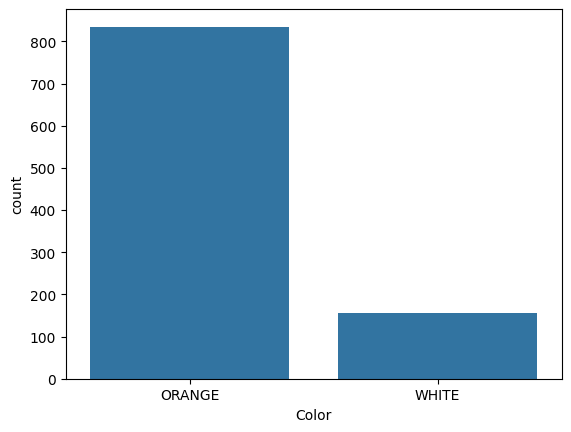

In [5]:
sns.countplot(data=df, x='Color')
plt.show()

# Data pre-processing

Let's encode features and labels to better plot the data and train the model

In [8]:
# Let's look at the different values of the 'Item Size' column
print(df['Item Size'].unique())


['med' 'lge' 'sml' 'xlge' 'med-lge' 'jbo' 'exjbo']


In [23]:
from sklearn.preprocessing import OrdinalEncoder
# Encode the 'Item Size' column using ordinal encoding
ordinal_features = ['Item Size']

ordinal_encoder = OrdinalEncoder(categories=[[ 'sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo' ]])


In [25]:
from sklearn.preprocessing import OneHotEncoder
# Encode all the other features using one-hot encoding
categorical_features = ['Variety', 'City Name', 'Package']

categorical_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [26]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('ord', ordinal_encoder, ordinal_features),
        ('cat', categorical_encoder, categorical_features)
    ]
)

# Get the encoded features as a pandas DataFrame
encoded_features = ct.fit_transform(df)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=ct.get_feature_names_out()
)

encoded_df.head()

,ord__Item Size,cat__Variety_BIG MACK TYPE,cat__Variety_BLUE TYPE,cat__Variety_CINDERELLA,cat__Variety_FAIRYTALE,cat__Variety_HOWDEN TYPE,cat__Variety_HOWDEN WHITE TYPE,cat__Variety_KNUCKLE HEAD,cat__Variety_MINIATURE,cat__Variety_PIE TYPE,...,cat__City Name_PHILADELPHIA,cat__City Name_SAN FRANCISCO,cat__City Name_ST. LOUIS,cat__Package_1 1/9 bushel cartons,cat__Package_1 1/9 bushel crates,cat__Package_1/2 bushel cartons,cat__Package_24 inch bins,cat__Package_36 inch bins,cat__Package_bins,cat__Package_bushel cartons
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [28]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Color' column using label encoding
label_encoder = LabelEncoder()

encoded_df["Color"] = label_encoder.fit_transform(df["Color"])

In [29]:
# Let's look at the mapping between the encoded values and the original values
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'ORANGE': np.int64(0), 'WHITE': np.int64(1)}


# Analysing relationships between features and label

In [ ]:
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}
# We need the encoded Item Size column to use it as the x-axis values in the plot

# Defining axis labels


Let's now focus on a specific relationship: Item Size and Color!

In [30]:
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

<Axes: xlabel='Color', ylabel='ord__Item Size'>

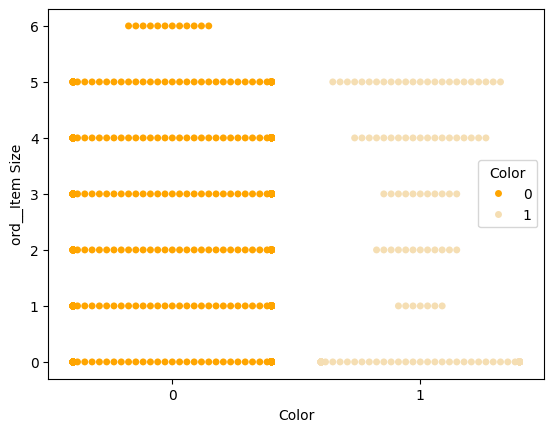

In [31]:
# Suppressing warning message claiming that a portion of points cannot be placed into the plot due to the high number of data points
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

palette = {
    0: 'orange',
    1: 'wheat'
}
sns.swarmplot(x="Color", y="ord__Item Size", hue="Color", data=encoded_df, palette=palette)

**Watch out**: Ignoring warnings is NOT a best practice and should be avoid, whenever possible. Warnings often contain useful messages that let us improve our code and solve an issue.
The reason why we are ignoring this specific warning is to guarantee the readability of the plot. Plotting all the data points with a reduced marker size, while keeping consistency with the palette color, generates an unclear visualization.

# Build your model

In [32]:
from sklearn.model_selection import train_test_split
# X is the encoded features
X = encoded_df.drop("Color", axis=1)
# y is the encoded label
y = encoded_df["Color"]
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model on the pumpkin dataset
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate the model and print the results
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

F1 Score: 0.7710843373493976
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       157
           1       0.78      0.76      0.77        42

    accuracy                           0.90       199
   macro avg       0.86      0.85      0.86       199
weighted avg       0.90      0.90      0.90       199



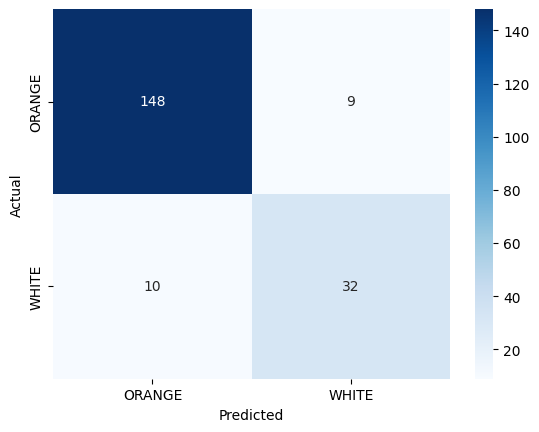

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()